In [3]:
import pyddm
import pyddm.plot
import pandas
import matplotlib.pyplot as plt

In [7]:
model = pyddm.gddm(drift="driftrate", bound="B", starting_position="x0", nondecision="ndtime",
                   parameters={"driftrate": (-1, 1), "B": (.5, 2), "x0": (-.5, .5), "ndtime": (0, .5)})
model.show()
df = pandas.read_csv("resultats.csv",sep=',')
sample = pyddm.Sample.from_pandas_dataframe(df, rt_column_name="rt", choice_column_name="correct")
model.fit(sample, verbose=False)

Model ndtime information:
Choices: 'correct' (upper boundary), 'error' (lower boundary)
Drift component DriftConstant:
    constant
    Fittable parameters:
    - drift: Fittable (default -0.160712)
Noise component NoiseConstant:
    constant
    Fixed parameters:
    - noise: 1.000000
Bound component BoundConstant:
    constant
    Fittable parameters:
    - B: Fittable (default 1.470745)
IC component ICPointRatio:
    An arbitrary starting point expressed as a proportion of the distance between the bounds.
    Fittable parameters:
    - x0: Fittable (default 0.014989)
Overlay component OverlayChain:
    Overlay component OverlayNonDecision:
        Add a non-decision by shifting the histogram
        Fittable parameters:
        - nondectime: Fittable (default 0.282933)
    Overlay component OverlayMixtureEasy:
        easy_mixture_model
        (No parameters)



Info: Params [-0.56475572  0.66533495 -0.04138249  0.38496811] gave 2323.145487817285


In [5]:
pyddm.plot.model_gui_jupyter(model)

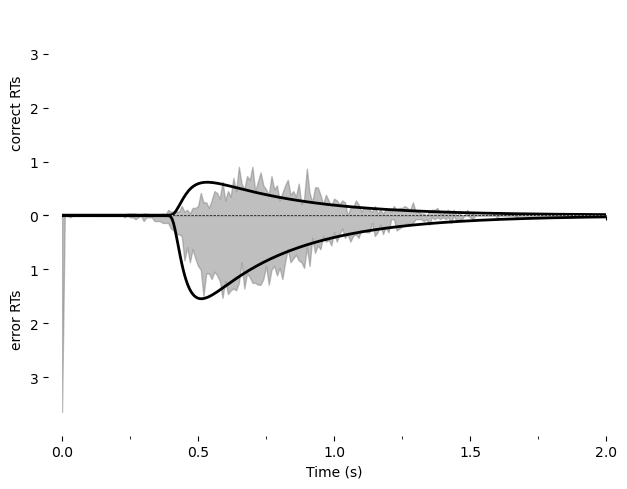

In [6]:
pyddm.plot.plot_fit_diagnostics(model=model, sample=sample)
plt.savefig("simple-fit.png")
plt.show()